# Fully Connected Autoencoder with SWaT Dataset 2020

In [37]:
import pandas as pd
import numpy as np

df = pd.read_csv("SWaT_cleaned_data_2020.csv")

print(df.shape)
df.head()

(32402, 61)


,P206.Status,MV501.Status,P203.Status,MV302.Status,MV101.Status,P4_STATE,P101.Status,P404.Status,P402.Status,P204.Status,...,AIT504.Pv,DPIT301.Pv,LIT401.Pv,LIT301.Pv,P1_STATE,FIT502.Pv,P502.Status,MV201.Status,P302.Status,P6_STATE
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.345552,3.755042,830.479400,1008.27515,1.0,0.002562,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.345552,3.755042,830.556300,1008.47540,1.0,0.002562,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.345552,3.755042,830.440900,1008.47540,1.0,0.002562,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.653166,3.755042,830.979248,1008.47540,1.0,0.002562,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.653166,3.755042,830.594700,1008.47540,1.0,0.002562,1.0,1.0,1.0,1.0


In [38]:
timestamps = pd.to_datetime(df['t_stamp'], errors='coerce')
df = df.drop(columns=['t_stamp'])

## Verificar valores faltantes

In [39]:
df.isna().sum().sum()

np.int64(60)

In [40]:
df = df.ffill()
df.isna().sum().sum()

np.int64(0)

## División temporal para normalizar

In [41]:
# División temporal train / validation / test
n = len(df)

train_end = int(n * 0.6)
val_end = int(n * 0.8)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (19441, 60)
Validation: (6480, 60)
Test: (6481, 60)


## Normalización

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df)
val_scaled   = scaler.transform(val_df)
test_scaled  = scaler.transform(test_df)

train_scaled = pd.DataFrame(train_scaled, columns=df.columns)
val_scaled   = pd.DataFrame(val_scaled, columns=df.columns)
test_scaled  = pd.DataFrame(test_scaled, columns=df.columns)

print(train_scaled.shape, val_scaled.shape, test_scaled.shape)

(19441, 60) (6480, 60) (6481, 60)


## Crear ventanas temporales

Empezar con L = 60, stride = 5

In [43]:
def create_windows(data, window_size=60, stride=5):

    windows = []

    for i in range(0, len(data) - window_size, stride):
        window = data[i:i+window_size]
        windows.append(window)

    return np.array(windows)

In [44]:
L = 60
stride = 5

train_windows = create_windows(train_scaled.values, window_size=L, stride=stride)
val_windows   = create_windows(val_scaled.values, window_size=L, stride=stride)
test_windows  = create_windows(test_scaled.values, window_size=L, stride=stride)

print("Train windows:", train_windows.shape)
print("Validation windows:", val_windows.shape)
print("Test windows:", test_windows.shape)

Train windows: (3877, 60, 60)
Validation windows: (1284, 60, 60)
Test windows: (1285, 60, 60)


## Aplanar ventanas para FC Autoencoder

In [45]:
n_train, L, n_features = train_windows.shape
X_train = train_windows.reshape(n_train, L * n_features)

n_val = val_windows.shape[0]
X_val = val_windows.reshape(n_val, L * n_features)

n_test = test_windows.shape[0]
X_test = test_windows.reshape(n_test, L * n_features)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (3877, 3600)
X_val: (1284, 3600)
X_test: (1285, 3600)


## Convertir a PyTorch

In [46]:
import torch
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

## Implementación FC Autoencoder

In [47]:
import torch.nn as nn

class FCAutoencoder(nn.Module):

    def __init__(self, input_dim):

        super(FCAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim)
        )

    def forward(self, x):

        z = self.encoder(x)
        x_hat = self.decoder(z)

        return x_hat

In [48]:
input_dim = X_train.shape[1]

model = FCAutoencoder(input_dim)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

## Definición de entrenamiento

In [49]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 30

## Entrenamiento

In [50]:
loss_history = []

for epoch in range(epochs):

    total_loss = 0

    for batch in train_loader:

        x = batch[0].to(device)

        optimizer.zero_grad()

        x_hat = model(x)

        loss = criterion(x_hat, x)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    epoch_loss = total_loss / len(train_loader)
    loss_history.append(epoch_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss}")

Epoch 1/30, Loss: 0.3055293371931451
Epoch 2/30, Loss: 0.11641005438859345
Epoch 3/30, Loss: 0.08885344462927247
Epoch 4/30, Loss: 0.07173022411030824
Epoch 5/30, Loss: 0.06616653987496603
Epoch 6/30, Loss: 0.06570532887441213
Epoch 7/30, Loss: 0.05885262002588296
Epoch 8/30, Loss: 0.05475874352039861
Epoch 9/30, Loss: 0.05283938517763478
Epoch 10/30, Loss: 0.04867018898185648
Epoch 11/30, Loss: 0.04692840194482295
Epoch 12/30, Loss: 0.051462478691437205
Epoch 13/30, Loss: 0.04411656479732912
Epoch 14/30, Loss: 0.04224596911522209
Epoch 15/30, Loss: 0.03940304437438484
Epoch 16/30, Loss: 0.039652434376175286
Epoch 17/30, Loss: 0.0389335086935612
Epoch 18/30, Loss: 0.04073576371139679
Epoch 19/30, Loss: 0.04349688312313596
Epoch 20/30, Loss: 0.03700820909293949
Epoch 21/30, Loss: 0.03881885048734848
Epoch 22/30, Loss: 0.041446975218590164
Epoch 23/30, Loss: 0.040935928658505934
Epoch 24/30, Loss: 0.04392755581218688
Epoch 25/30, Loss: 0.04282928542157666
Epoch 26/30, Loss: 0.03664713804

## Curva de entrenamiento

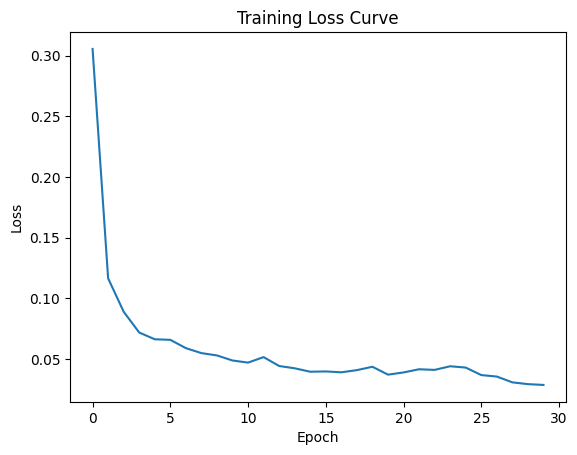

In [51]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

## Error de reconstrucción

### Error en validation para definir el umbral

In [52]:
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)

model.eval()

val_reconstruction_errors = []

with torch.no_grad():
    x_val = X_val_tensor.to(device)
    x_val_hat = model(x_val)

    val_error = torch.mean((x_val - x_val_hat)**2, dim=1)
    val_reconstruction_errors = val_error.cpu().numpy()

### Error en test para FAR

In [53]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

test_reconstruction_errors = []

with torch.no_grad():
    x_test = X_test_tensor.to(device)
    x_test_hat = model(x_test)

    test_error = torch.mean((x_test - x_test_hat)**2, dim=1)
    test_reconstruction_errors = test_error.cpu().numpy()

### Histograma de validation

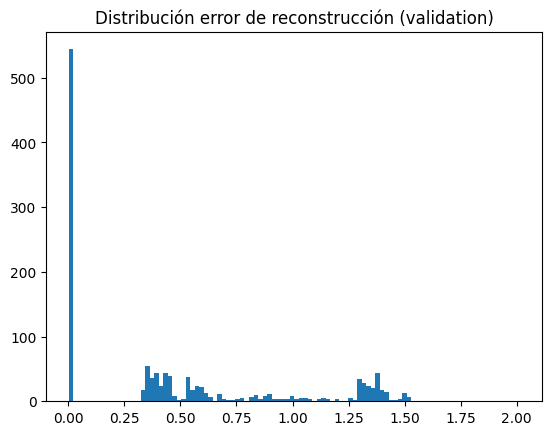

In [54]:
plt.hist(val_reconstruction_errors, bins=100)
plt.title("Distribución error de reconstrucción (validation)")
plt.show()

## Percentiles

In [55]:
np.percentile(val_reconstruction_errors, [90, 95, 97.5, 99])

array([1.34755241, 1.38790043, 1.42556469, 1.50819829])

## Cálculo de FAR

### Umbrales

In [56]:
tau_95 = np.percentile(val_reconstruction_errors, 95)
tau_975 = np.percentile(val_reconstruction_errors, 97.5)
tau_99 = np.percentile(val_reconstruction_errors, 99)

### FAR sobre test

In [57]:
far_95 = np.mean(test_reconstruction_errors > tau_95)
far_975 = np.mean(test_reconstruction_errors > tau_975)
far_99 = np.mean(test_reconstruction_errors > tau_99)

print("FAR @ P95:", far_95 * 100, "%")
print("FAR @ P97.5:", far_975 * 100, "%")
print("FAR @ P99:", far_99 * 100, "%")

FAR @ P95: 2.1011673151750974 %
FAR @ P97.5: 1.9455252918287937 %
FAR @ P99: 1.634241245136187 %


In [58]:

print("Val error mean:", np.mean(val_reconstruction_errors))
print("Test error mean:", np.mean(test_reconstruction_errors))


print("Val error median:", np.median(val_reconstruction_errors))
print("Test error median:", np.median(test_reconstruction_errors))

Val error mean: 0.46662775
Test error mean: 0.6652678
Val error median: 0.38067096
Test error median: 0.58479255
